# Module 1 — Loan Default Risk Prediction

**Business Question:** Which borrowers are likely to default on their loan?

**Task Type:** Binary Classification
- Target: `default_flag` → 0 = Fully Paid, 1 = Charged Off

**Models compared:**
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost (champion)

**Pipeline:**
```
Load processed data → Feature selection → Train/test split → 
Handle class imbalance (SMOTE) → Train 3 models → Evaluate → SHAP explainability
```

In [13]:
import os
os.chdir(r'C:\Users\User\Documents\finsight-forecasting')
print(os.getcwd())

C:\Users\User\Documents\finsight-forecasting


## 1. Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalanced data
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Explainability
import shap

# Model saving
import joblib
import os

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Processed Data

In [14]:
df = pd.read_csv('data/processed/loans_cleaned.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (1344936, 96)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default_flag,issue_year,issue_month
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,2015,12
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,2015,12
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,2015,12


In [15]:
# Check class distribution
print('Default flag distribution:')
print(df['default_flag'].value_counts())
print()
print(f'Default rate: {df["default_flag"].mean():.2%}')

Default flag distribution:
default_flag
0    1076448
1     268488
Name: count, dtype: int64

Default rate: 19.96%


## 3. Feature Selection

We select features that are:
- Available at the time of loan application (no data leakage)
- Financially meaningful
- Not redundant

In [16]:
# Features available at loan application time — no leakage
FEATURES = [
    'loan_amnt',       # loan amount requested
    'int_rate',        # interest rate
    'installment',     # monthly payment
    'annual_inc',      # annual income
    'dti',             # debt-to-income ratio
    'delinq_2yrs',     # delinquencies in past 2 years
    'inq_last_6mths',  # credit inquiries in last 6 months
    'open_acc',        # number of open credit lines
    'pub_rec',         # public derogatory records
    'revol_util',      # revolving line utilization rate
    'total_acc',       # total credit lines
    'emp_length',      # employment length (years)
    'grade',           # loan grade assigned by Lending Club
    'home_ownership',  # renter / owner / mortgage
    'purpose',         # reason for loan
    'issue_year',      # year loan was issued
    'issue_month',     # month loan was issued
]

TARGET = 'default_flag'

# Keep only selected features + target
df_model = df[FEATURES + [TARGET]].copy()
print(f'Model dataset shape: {df_model.shape}')
df_model.isnull().sum()

Model dataset shape: (1344936, 18)


loan_amnt             0
int_rate              0
installment           0
annual_inc            0
dti                   0
delinq_2yrs           0
inq_last_6mths        1
open_acc              0
pub_rec               0
revol_util          856
total_acc             0
emp_length        78154
grade                 0
home_ownership        0
purpose               0
issue_year            0
issue_month           0
default_flag          0
dtype: int64

## 4. Feature Engineering

In [17]:
# Encode categorical columns
cat_cols = ['grade', 'home_ownership', 'purpose']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# Fill remaining nulls with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

print('Encoding complete. Null values remaining:')
print(df_model.isnull().sum().sum())

Encoding complete. Null values remaining:
0


## 5. Train / Test Split

In [18]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve class ratio
)

print(f'Training set:   {X_train.shape}')
print(f'Test set:       {X_test.shape}')
print(f'Default rate in train: {y_train.mean():.2%}')
print(f'Default rate in test:  {y_test.mean():.2%}')

Training set:   (1075948, 17)
Test set:       (268988, 17)
Default rate in train: 19.96%
Default rate in test:  19.96%


## 6. Handle Class Imbalance with SMOTE

The dataset is imbalanced (~80% repaid, ~20% default).  
SMOTE (Synthetic Minority Oversampling Technique) generates synthetic default samples so the model does not simply predict 'Fully Paid' for everything.

In [19]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_bal).value_counts())

Before SMOTE:
default_flag
0    861158
1    214790
Name: count, dtype: int64


  File "C:\Users\User\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\User\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Program Files\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python310\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



After SMOTE:
default_flag
0    861158
1    861158
Name: count, dtype: int64


## 7. Train Models

In [20]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

# --- Model 1: Logistic Regression (baseline) ---
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_bal)
print('Done.')

Training Logistic Regression...
Done.


In [21]:
# --- Model 2: Random Forest ---
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)
print('Done.')

Training Random Forest...
Done.


In [28]:
# --- Model 3: XGBoost ---
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_bal)
print('Done.')

Training XGBoost...
Done.


## 8. Evaluate Models

In [ ]:
def evaluate_model(name, model, X_test, y_test, scaled=False, threshold=0.5):
    """Print AUC, classification report, and return AUC score."""
    X_input = X_test_scaled if scaled else X_test
    y_prob  = model.predict_proba(X_input)[:, 1]
    y_pred  = (y_prob >= threshold).astype(int)
    auc     = roc_auc_score(y_test, y_prob)

    print(f'\n{"-"*50}')
    print(f'Model: {name}  |  Threshold: {threshold}')
    print(f'AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))
    return auc

# Logistic Regression and Random Forest use the default threshold of 0.5.
auc_lr  = evaluate_model('Logistic Regression', lr,  X_test, y_test, scaled=True)
auc_rf  = evaluate_model('Random Forest', rf,  X_test, y_test)

# XGBoost uses a threshold of 0.3.
auc_xgb = evaluate_model('XGBoost', xgb, X_test, y_test, threshold=0.3)


--------------------------------------------------
Model: Logistic Regression  |  Threshold: 0.5
AUC-ROC: 0.6597
              precision    recall  f1-score   support

  Fully Paid       0.85      0.69      0.76    215290
 Charged Off       0.30      0.53      0.38     53698

    accuracy                           0.66    268988
   macro avg       0.58      0.61      0.57    268988
weighted avg       0.74      0.66      0.69    268988


--------------------------------------------------
Model: Random Forest  |  Threshold: 0.5
AUC-ROC: 0.6831
              precision    recall  f1-score   support

  Fully Paid       0.83      0.88      0.85    215290
 Charged Off       0.37      0.28      0.31     53698

    accuracy                           0.76    268988
   macro avg       0.60      0.58      0.58    268988
weighted avg       0.74      0.76      0.75    268988


--------------------------------------------------
Model: XGBoost  |  Threshold: 0.3
AUC-ROC: 0.7168
              precisio

## 9. Model Comparison — ROC Curves

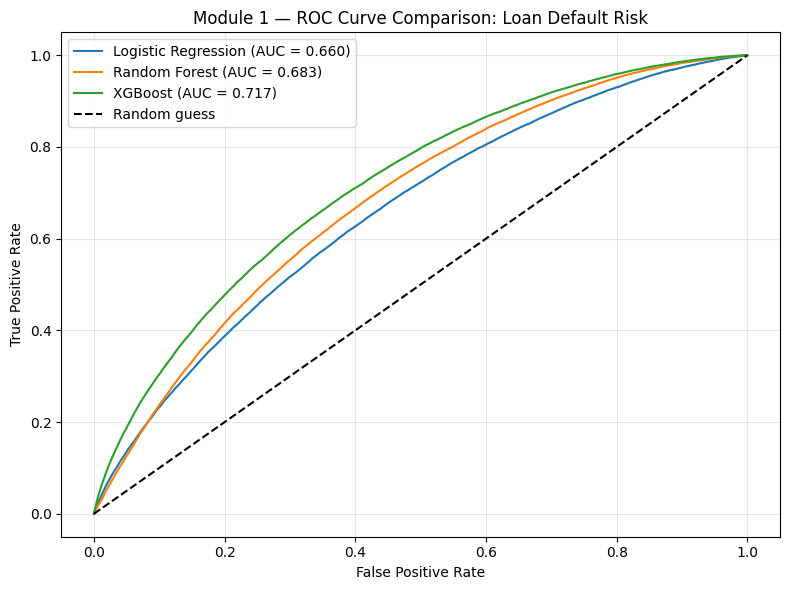

ROC curve saved to reports/


In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, scaled in [
    ('Logistic Regression', lr,  True),
    ('Random Forest',       rf,  False),
    ('XGBoost',             xgb, False),
]:
    X_input = X_test_scaled if scaled else X_test
    y_prob  = model.predict_proba(X_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Module 1 — ROC Curve Comparison: Loan Default Risk')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/module1_roc_curve.png', dpi=150)
plt.show()
print('ROC curve saved to reports/')

## 10. Confusion Matrix — XGBoost

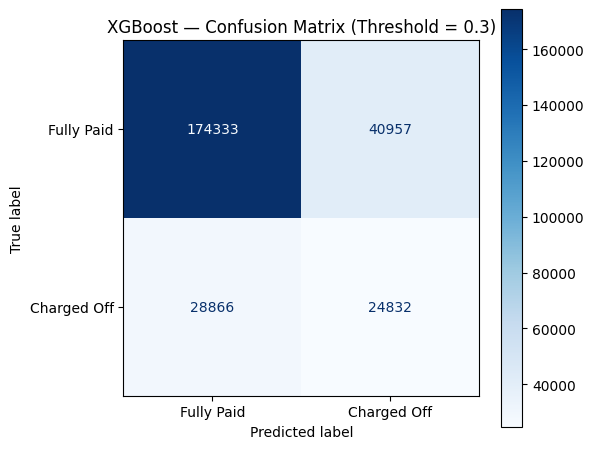

In [ ]:
# Prediction results using threshold 0.3
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.3).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Fully Paid', 'Charged Off'],
    cmap='Blues',
    ax=ax
)
ax.set_title('XGBoost — Confusion Matrix (Threshold = 0.3)')
plt.tight_layout()
plt.savefig('reports/module1_confusion_matrix.png', dpi=150)
plt.show()

## 11. SHAP — Feature Importance (XGBoost)

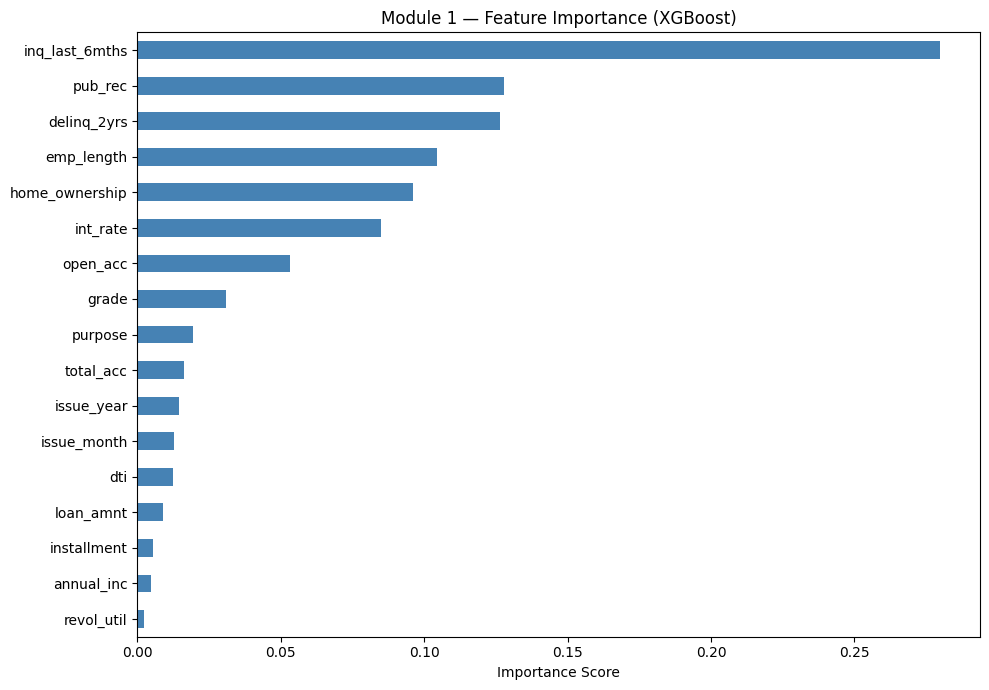

Feature importance plot saved to reports/


In [37]:
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_test.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Module 1 — Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('reports/module1_shap.png', dpi=150)
plt.show()
print('Feature importance plot saved to reports/')

## 12. Model Comparison Summary

In [38]:
results = pd.DataFrame({
    'Model':   ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [round(auc_lr, 4), round(auc_rf, 4), round(auc_xgb, 4)]
})

results = results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results.index += 1
print('Module 1 — Model Comparison')
print(results.to_string())

Module 1 — Model Comparison
                 Model  AUC-ROC
1              XGBoost   0.7168
2        Random Forest   0.6831
3  Logistic Regression   0.6597


## 13. Save Best Model

In [39]:
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

joblib.dump(xgb,    'models/module1_xgb.pkl')
joblib.dump(rf,     'models/module1_rf.pkl')
joblib.dump(lr,     'models/module1_lr.pkl')
joblib.dump(scaler, 'models/module1_scaler.pkl')

# Save feature list for dashboard use
joblib.dump(FEATURES, 'models/module1_features.pkl')

print('All models saved to models/')

All models saved to models/
